In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
colors = sns.color_palette().as_hex()
ambiente_pallete = {
    'Notebook': colors[0],
    'Servidor': colors[1]
}
tipo_pallete = {
    'Seq': colors[4],
    'Rand': colors[3]
}

df_notebook = pd.read_csv('../data/btree_notebook_sem_reuso.csv')
df_servidor = pd.read_csv('../data/btree_servidor_sem_reuso.csv')

df_notebook['Ambiente'] = 'Notebook'
df_servidor['Ambiente'] = 'Servidor'

df_total = pd.concat([df_notebook, df_servidor], ignore_index=True)
df_base = df_notebook.copy()

## PARTE 1: Validação Teórica da Árvore B
O objetivo primário da implementação da Árvore B é a redução de operações de I/O em memória secundária. Essa seção comprova matematicamente o comportamento da estrutura perante a variação da ordem (M), independentemente do hardware utilizado.

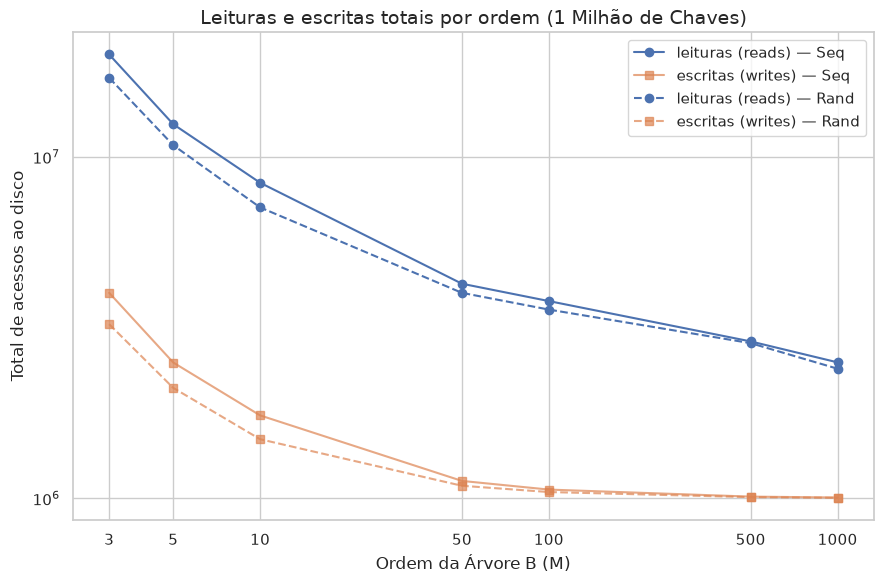

In [2]:
df_teoria_1m = df_base[df_base['numKeys'] == 1000000].copy()

plt.figure(figsize=(9, 6))
for tipo, ls in [('Seq', '-'), ('Rand', '--')]:
    d = df_teoria_1m[df_teoria_1m['tipo'] == tipo].sort_values('M')
    plt.plot(d['M'], d['reads'], marker='o', ls=ls, color=colors[0],
             label=f'leituras (reads) — {tipo}')
    plt.plot(d['M'], d['writes'], marker='s', ls=ls, color=colors[1],
             alpha=0.7, label=f'escritas (writes) — {tipo}')

plt.title('Leituras e escritas totais por ordem (1 Milhão de Chaves)', fontsize=14)
plt.xlabel('Ordem da Árvore B (M)', fontsize=12)
plt.ylabel('Total de acessos ao disco', fontsize=12)
plt.xscale('log')
plt.yscale('log')
plt.xticks(df_teoria_1m['M'].unique(), df_teoria_1m['M'].unique())
plt.legend()
plt.tight_layout()
plt.show()

Este gráfico mostra **quantas leituras e quantas escritas** a estrutura faz no total (não a média por operação). Com ordem pequena (M=3), a árvore é alta e cada inserção percorre muitos nós → cerca de **21 milhões de leituras**. Ao aumentar M, a árvore achata e o total de acessos cai uma ordem de magnitude (≈2,5 milhões de leituras em M=1000). As **leituras superam as escritas** em toda a faixa: cada inserção lê o caminho inteiro da raiz à folha, mas só reescreve os nós efetivamente alterados.

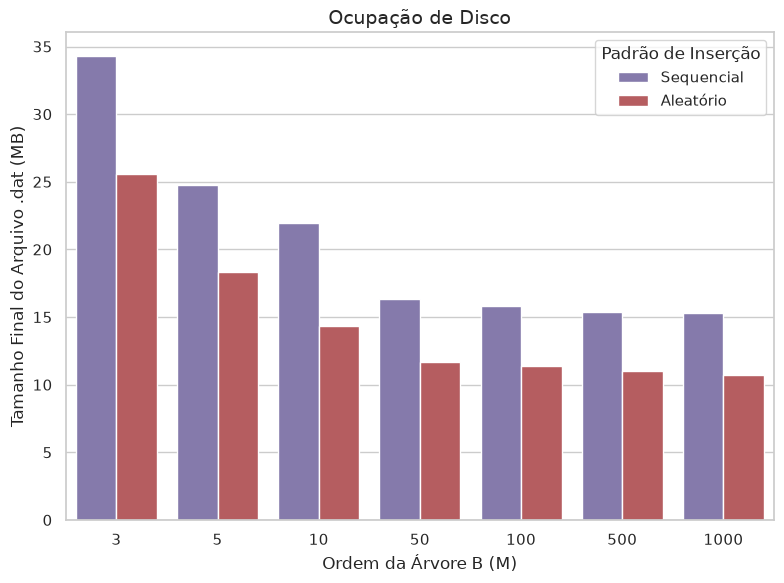

In [3]:
plt.figure(figsize=(8, 6))

df_teoria_1m['Tamanho (MB)'] = df_teoria_1m['bytes'] / (1024 * 1024)

sns.barplot(data=df_teoria_1m, x='M', y='Tamanho (MB)', hue='tipo', 
            palette=tipo_pallete)

plt.title('Ocupação de Disco', fontsize=14)
plt.xlabel('Ordem da Árvore B (M)', fontsize=12)
plt.ylabel('Tamanho Final do Arquivo .dat (MB)', fontsize=12)
leg = plt.legend(title='Padrão de Inserção')
leg.get_texts()[0].set_text('Sequencial')
leg.get_texts()[1].set_text('Aleatório')

plt.tight_layout()
plt.show()

Aqui provamos a matemática do preenchimento dos nós. A inserção puramente sequencial gera partições apenas à direita, deixando nós internos subutilizados. A inserção aleatória distribui as chaves e aproveita melhor os blocos, gerando um arquivo final menor.

## PARTE 2: Tempo de Execução — Page Cache vs. Disco Real (CPU vs. I/O)

O número **lógico** de acessos (`reads`/`writes`) é o mesmo em qualquer máquina — é a métrica que a teoria manda minimizar. Já o **tempo** desses acessos depende de onde os dados realmente estão na hora.

**Ponto crítico (o cache de RAM).** O arquivo `.dat` de 10⁶ chaves ocupa de 11 a 36 MB e **cabe inteiro na RAM**. Logo, o **page cache do sistema operacional** serve quase todas as leituras/escritas, e o `tempo_io` medido reflete **memória + syscalls + memcpy**, *não* a mecânica do disco (o dispositivo aqui é um **SSD NVMe**, sem agulha nem latência rotacional de 5400 RPM).

**Como contornamos (opção 2).** Para medir I/O *real*, limitamos a RAM do processo com um **cgroup** (`systemd-run --user -p MemoryHigh=8M`), forçando o page cache a ficar menor que o arquivo — assim os acessos passam a bater no dispositivo. Comparamos os dois regimes (`cacheado` × `restrito`) em `data/resultados_io_real.csv`. As contagens lógicas (`reads`/`writes`/`bytes`/`altura`) são **idênticas** entre os modos; só o tempo muda.

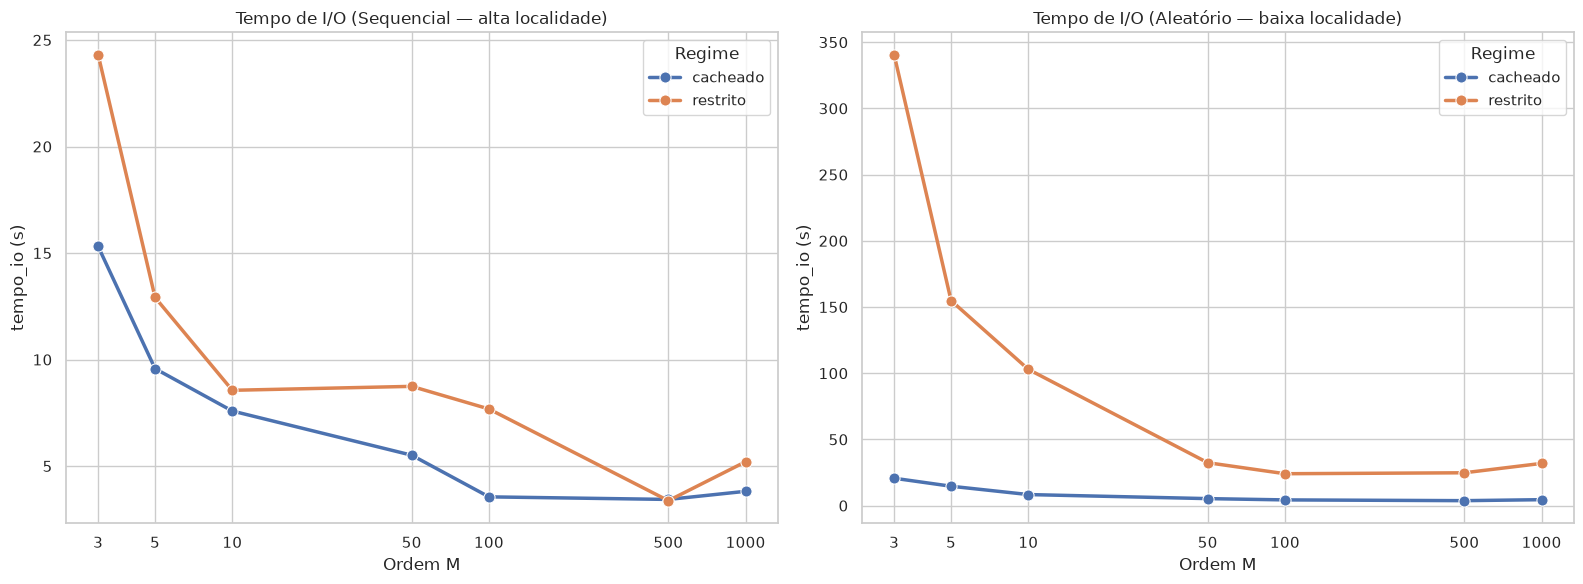

In [4]:
df_io = pd.read_csv('../data/resultados_io_real.csv')
df_io_1m = df_io[df_io['numKeys'] == 1000000].copy()
modo_pallete = {'cacheado': colors[0], 'restrito': colors[1]}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, tipo, titulo in zip(
        axes, ['Seq', 'Rand'],
        ['Sequencial — alta localidade', 'Aleatório — baixa localidade']):
    d = df_io_1m[df_io_1m['tipo'] == tipo]
    sns.lineplot(ax=ax, data=d, x='M', y='tempo_io', hue='modo',
                 marker='o', linewidth=2.5, markersize=8, palette=modo_pallete)
    ax.set_title(f'Tempo de I/O ({titulo})')
    ax.set_xlabel('Ordem M'); ax.set_ylabel('tempo_io (s)')
    ax.set_xscale('log')
    ax.set_xticks(d['M'].unique()); ax.set_xticklabels(d['M'].unique())
    ax.legend(title='Regime')
plt.tight_layout()
plt.show()

O contraste é o ponto central. Na inserção **sequencial** (esquerda), limitar a RAM quase não muda o `tempo_io`: o *working set* é apenas a espinha direita da árvore (poucos nós, sempre os mesmos), que cabe em qualquer cache — o I/O é inerentemente **local**. Já a inserção **aleatória** (direita) **dispara** sob restrição: cada chave desce um caminho aleatório, o *working set* é a árvore inteira, e com a RAM limitada os acessos viram I/O real no NVMe.

Isso prova duas coisas: (1) os tempos "cacheados" **não** mediam o disco — senão limitar o cache não mudaria nada; e (2) o que governa o custo real não é só a *contagem* de acessos, mas a **localidade** deles (a "localização das referências" da teoria de memória secundária).

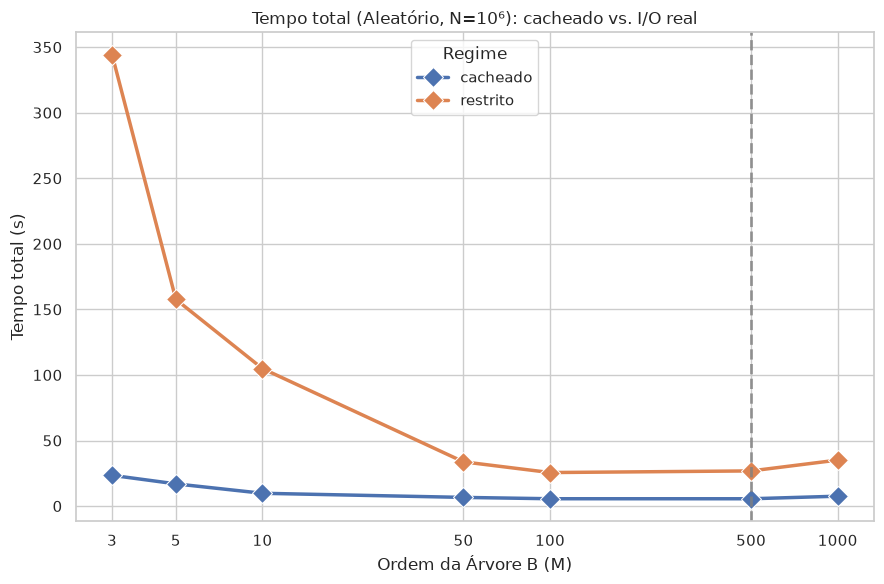

In [5]:
plt.figure(figsize=(9, 6))
d = df_io_1m[df_io_1m['tipo'] == 'Rand']
sns.lineplot(data=d, x='M', y='tempo_total', hue='modo',
             marker='D', markersize=10, linewidth=2.5, palette=modo_pallete)
plt.title('Tempo total (Aleatório, N=10⁶): cacheado vs. I/O real')
plt.xlabel('Ordem da Árvore B (M)'); plt.ylabel('Tempo total (s)')
plt.xscale('log'); plt.xticks(d['M'].unique(), d['M'].unique())
# No = pagina de disco (~4 KB) por volta de M=500 nesta struct: o otimo teorico de disco.
plt.axvline(x=500, color='gray', linestyle='--', alpha=0.8, linewidth=2)
plt.legend(title='Regime')
plt.tight_layout()
plt.show()

**Ordem ótima — e por que ela depende do hardware.** Em memória (`cacheado`), o tempo mínimo fica em torno de **M≈100**. Forçando I/O real (`restrito`, Aleatório), o mínimo **continua em ~M≈100** (≈26 s) — ele *não* migra para a "página de disco" (M≈500–1000, linha tracejada). O motivo é o dispositivo: a teoria (AED-03, slides 47–52) coloca o ótimo no nó = página (4–8 KB) **porque assume um disco dominado por *seek*** (cada acesso paga ~10 ms de posicionamento, que compensa amortizar com nós grandes). Este hardware é um **SSD NVMe, sem *seek***: o custo passa a ser dominado pelos *bytes transferidos* (∝ M), e nós grandes (M=1000 → 8 KB/nó) ficam mais caros de mover do que nós pequenos, mesmo fazendo menos acessos. Por isso o ótimo permanece pequeno.

Conclusão honesta: **não existe um "M ótimo" universal** — ele depende de o gargalo ser o cache (memória), a transferência (SSD) ou o *seek* (HDD). Reproduzir o ótimo "nó = página" da literatura exigiria um disco mecânico. A única afirmação independente de máquina é a **contagem de acessos** (Parte 1).

## PARTE 3: Altura, Reaproveitamento de Nós e Mapa das Perguntas
As Partes 1 e 2 cobriram acessos a disco, ocupação e tempo (CPU vs I/O). Aqui fechamos as duas perguntas restantes do enunciado — **altura da árvore** (vs. M e vs. N) e **ocupação com vs. sem reaproveitamento de nós** — e consolidamos o mapa de todas as perguntas (Q1–Q8). Estas células usam a varredura canônica local `data/resultados_experimentos.csv` (que inclui a coluna `altura`) e `data/reuso_comparacao.csv`.

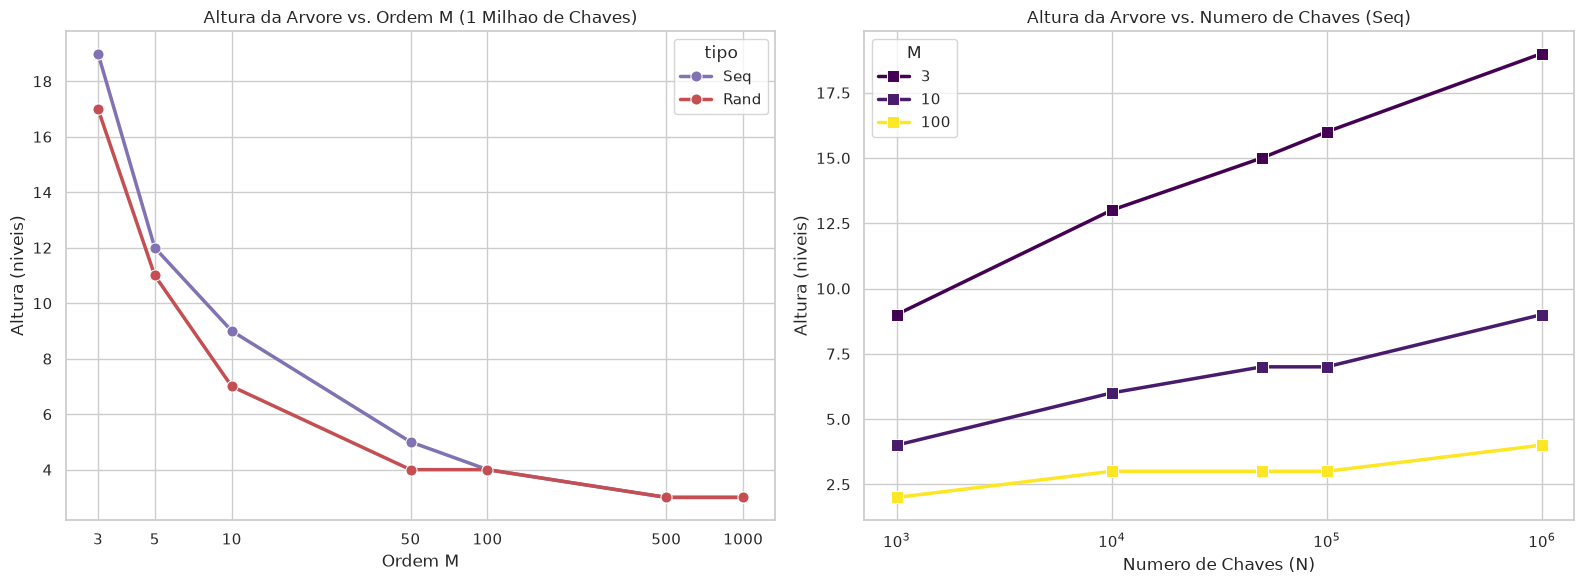

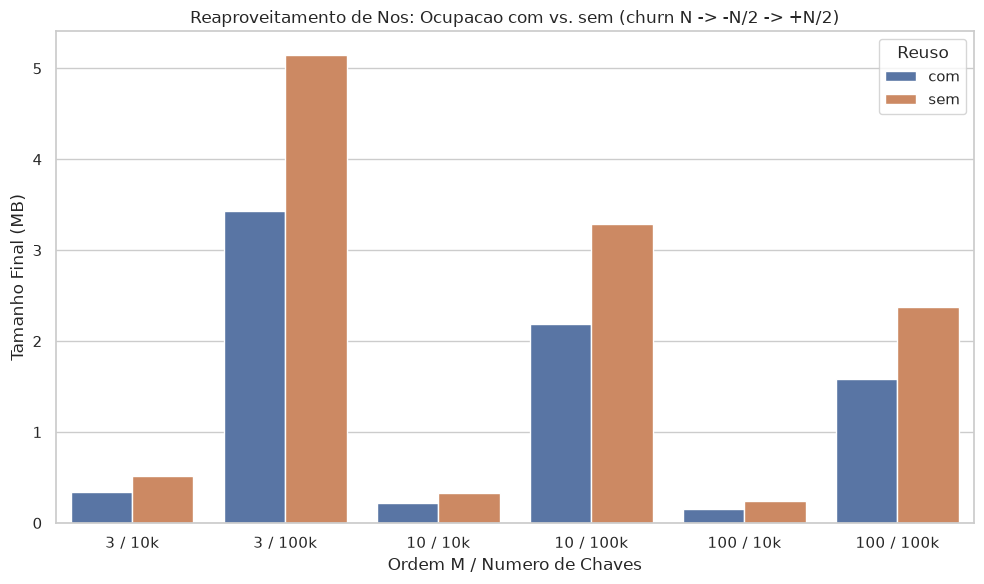

In [6]:
# A varredura canonica local inclui a coluna 'altura'; a comparacao de reuso
# tem as ocupacoes com/sem reaproveitamento. As mesmas figuras sao geradas por
# analysis/gerar_graficos.py (make graficos) e embutidas nos slides.
df_alt = pd.read_csv('../data/resultados_experimentos.csv')
df_reuso = pd.read_csv('../data/reuso_comparacao.csv')

# --- Altura: vs. Ordem M (1M de chaves) e vs. Numero de chaves N ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_alt_1m = df_alt[df_alt['numKeys'] == 1000000]
sns.lineplot(ax=axes[0], data=df_alt_1m, x='M', y='altura', hue='tipo',
             marker='o', linewidth=2.5, markersize=8, palette=tipo_pallete)
axes[0].set_title('Altura da Arvore vs. Ordem M (1 Milhao de Chaves)')
axes[0].set_xlabel('Ordem M'); axes[0].set_ylabel('Altura (niveis)')
axes[0].set_xscale('log')
axes[0].set_xticks(df_alt_1m['M'].unique())
axes[0].set_xticklabels(df_alt_1m['M'].unique())

df_alt_seq = df_alt[(df_alt['tipo'] == 'Seq') & (df_alt['M'].isin([3, 10, 100]))]
sns.lineplot(ax=axes[1], data=df_alt_seq, x='numKeys', y='altura', hue='M',
             marker='s', linewidth=2.5, markersize=8, palette='viridis')
axes[1].set_title('Altura da Arvore vs. Numero de Chaves (Seq)')
axes[1].set_xlabel('Numero de Chaves (N)'); axes[1].set_ylabel('Altura (niveis)')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

# --- Ocupacao: com vs. sem reaproveitamento de nos ---
plt.figure(figsize=(10, 6))
df_reuso['Tamanho (MB)'] = df_reuso['bytes'] / (1024 * 1024)
df_reuso['Cenario'] = (df_reuso['M'].astype(str) + ' / '
                       + (df_reuso['numKeys'] // 1000).astype(str) + 'k')
sns.barplot(data=df_reuso, x='Cenario', y='Tamanho (MB)', hue='reuso',
            palette={'com': colors[0], 'sem': colors[1]})
plt.title('Reaproveitamento de Nos: Ocupacao com vs. sem (churn N -> -N/2 -> +N/2)')
plt.xlabel('Ordem M / Numero de Chaves'); plt.ylabel('Tamanho Final (MB)')
plt.legend(title='Reuso')
plt.tight_layout()
plt.show()

**Altura.** A altura confirma o limite teórico $h \approx \log_M N$: cresce devagar com o número de chaves e cai bruscamente com a ordem — de 19 níveis em M=3 para apenas 3–4 níveis em M≥100 (com $N=10^6$). É a causa direta da queda no número de leituras médias por operação.

**Reaproveitamento de nós.** No workload de *churn* (insere N, remove N/2, reinsere N/2), reciclar os nós liberados pela "lixeira" mantém o arquivo ~1/3 menor do que sem reuso, de forma consistente em todas as ordens e volumes testados.

### Mapa das perguntas do enunciado (Q1–Q8)
| # | Pergunta experimental | Onde é respondida |
|---|---|---|
| Q1 | Como a ordem M afeta os acessos a disco? | Parte 1 (avg_reads vs M) |
| Q2 | Conjuntos de 10³ a 10⁶, Seq e Aleatório | varredura completa (70 execuções) |
| Q3 | Nº médio de acessos por operação | Parte 1 (avg_reads) |
| Q4 | Ocupação do arquivo (com e sem reuso) | Parte 1 (ocupação) + Parte 3 (reuso) |
| Q5 | Tempo de execução: CPU vs I/O | Parte 2 (tempo_io / tempo_cpu) |
| Q6 | Inserção Sequencial vs Aleatória | Partes 1 e 3 (hue por tipo) |
| Q7 | Altura da árvore vs M e vs N | Parte 3 (altura) |
| Q8 | Existe uma ordem M ótima? | Parte 2 (trade-off, ~M=100–500) |

> As figuras consolidadas usadas nos slides são geradas por `analysis/gerar_graficos.py` (`make graficos`), a partir de `data/resultados_experimentos.csv` e `data/reuso_comparacao.csv`.